In [27]:
import pandas as pd
from pathlib import Path

In [28]:
BASE_DIR = Path.cwd().parent  
RAW = BASE_DIR / "data" / "master"
df_original = pd.read_csv(RAW / "abuja_rental_master.csv")

In [29]:
df_original.head()

,District,Bedrooms,Price (Per Annum),Property Category,Property Type,Location,Scraped_At,Source
0,Kubwa,1,600000.0,Apartment,Self Contain,"Studio Apartment in Arab Road, Kubwa for rent",2026-05-30 13:25:47,Jiji
1,Kubwa,1,1500000.0,Apartment,Apartment,"1bdrm Block of Flats in Arab Road, Kubwa for rent",2026-05-30 13:25:47,Jiji
2,Life Camp,1,1200000.0,Apartment,Self Contain,"Studio Apartment in Efab City Estate, Life Cam...",2026-05-30 13:25:47,Jiji
3,Kubwa,1,1200000.0,Apartment,Apartment,"1bdrm Apartment in Arab Road, Kubwa for rent",2026-05-30 13:25:47,Jiji
4,Life Camp,2,1140000.0,Apartment,Apartment,Furnished 2bdrm Apartment in Life Camp for rent,2026-05-30 13:25:47,Jiji


In [30]:
df = df_original.copy()

In [31]:
print(df.shape)
print(df.info())
print(df.describe())

(4528, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4528 entries, 0 to 4527
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   District           4528 non-null   object 
 1   Bedrooms           4528 non-null   int64  
 2   Price (Per Annum)  4528 non-null   float64
 3   Property Category  4528 non-null   object 
 4   Property Type      4528 non-null   object 
 5   Location           4528 non-null   object 
 6   Scraped_At         4528 non-null   object 
 7   Source             4528 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 283.1+ KB
None
          Bedrooms  Price (Per Annum)
count  4528.000000       4.528000e+03
mean      3.290636       5.796277e+07
std       2.290650       1.065618e+09
min       1.000000       3.000000e+04
25%       2.000000       6.000000e+06
50%       3.000000       1.200000e+07
75%       4.000000       2.012500e+07
max      96.000000       4.7965

In [32]:
#cap number of bedrooms to 6
df = df[df['Bedrooms'] <= 6]

In [33]:
#cap price at 150,000,000
df = df[df['Price (Per Annum)'] <= 150_000_000]

In [35]:
print(df.describe())
print(df.shape)

          Bedrooms  Price (Per Annum)
count  4406.000000       4.406000e+03
mean      3.146845       1.684507e+07
std       1.258433       1.797443e+07
min       1.000000       3.000000e+04
25%       2.000000       6.000000e+06
50%       3.000000       1.100000e+07
75%       4.000000       2.000000e+07
max       6.000000       1.500000e+08
(4406, 8)


In [39]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
df.shape

Duplicate rows: 91


(4315, 8)

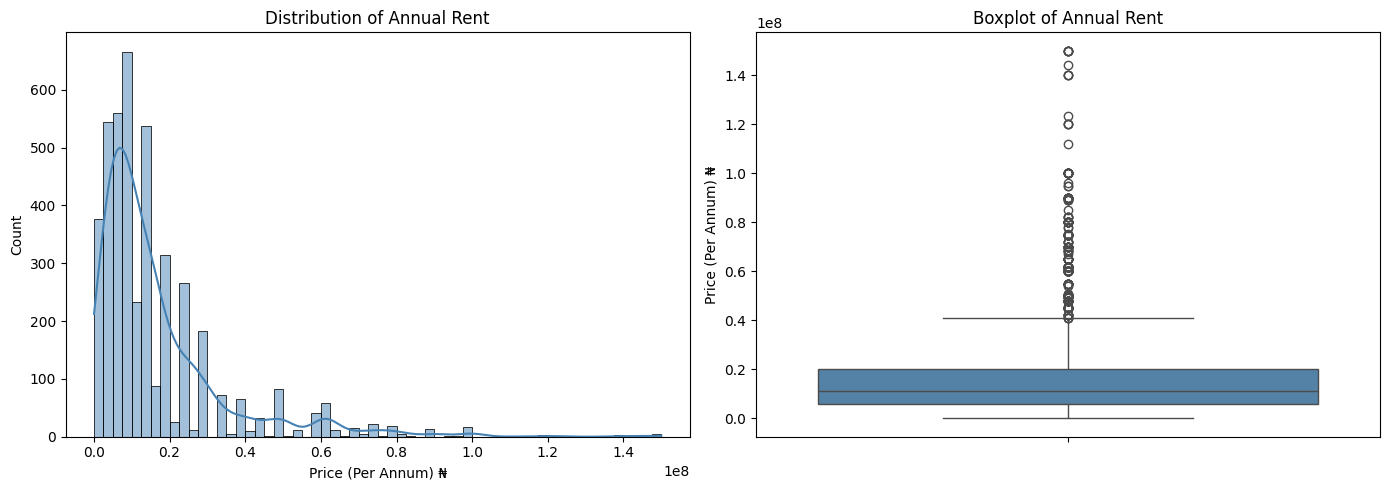

In [43]:
import seaborn as sns
from matplotlib import pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Price (Per Annum)'], bins=60, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Annual Rent')
axes[0].set_xlabel('Price (Per Annum) ₦')
axes[0].set_ylabel('Count')


sns.boxplot(y=df['Price (Per Annum)'], ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot of Annual Rent')
axes[1].set_ylabel('Price (Per Annum) ₦')
plt.tight_layout()
plt.show()

In [49]:
print(df['Bedrooms'].value_counts().sort_index())

Bedrooms
1     584
2     726
3    1095
4    1430
5     367
6     113
Name: count, dtype: int64


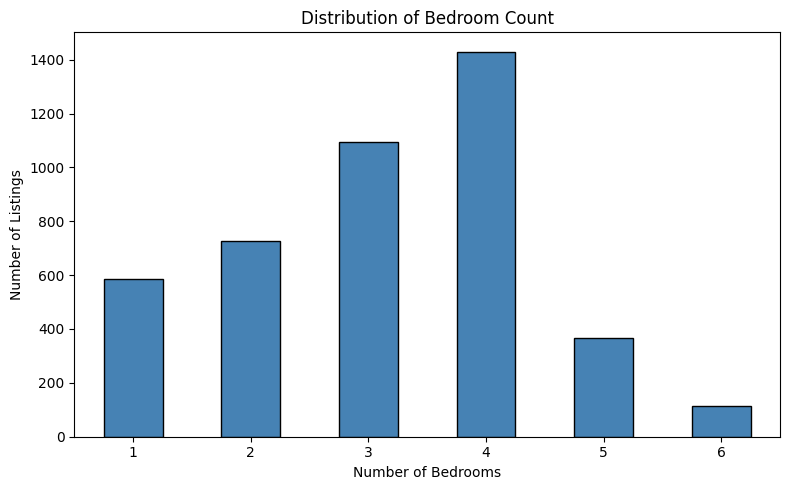

In [50]:
plt.figure(figsize=(8, 5))
df['Bedrooms'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribution of Bedroom Count')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Number of Listings')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

3 and 4-bedroom properties make up the largest share of listings, which reflects the typical family rental demand in Abuja. 1-bedroom and 6-bedroom units are noticeably less common.

In [ ]:
print(df['Property Category'].value_counts())

Property Category
Duplex       2034
Apartment    2028
House         157
Bungalow       96
Name: count, dtype: int64


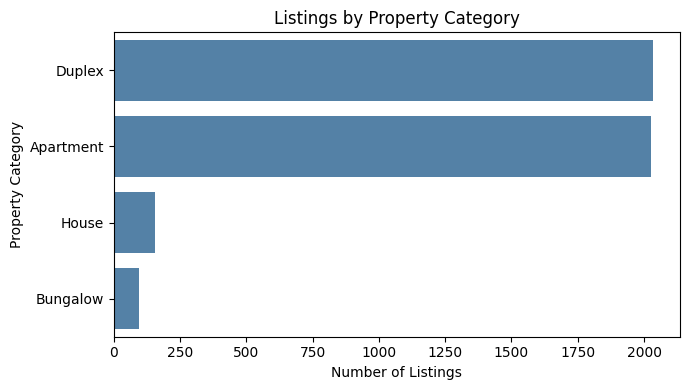

In [53]:
plt.figure(figsize=(7, 4))
order = df['Property Category'].value_counts().index
sns.countplot(data=df, y='Property Category', order=order,  color='steelblue')
plt.title('Listings by Property Category')
plt.xlabel('Number of Listings')
plt.ylabel('Property Category')
plt.tight_layout()
plt.show()

In [54]:
print(df['Property Type'].value_counts())

Property Type
Apartment                 1724
Terraced Duplex           1018
Detached Duplex            789
Self Contain               236
Semi-Detached Duplex       227
House                      157
Detached Bungalow           86
Mini Flat                   68
Semi-detached Bungalow       9
Terraced Bungalow            1
Name: count, dtype: int64


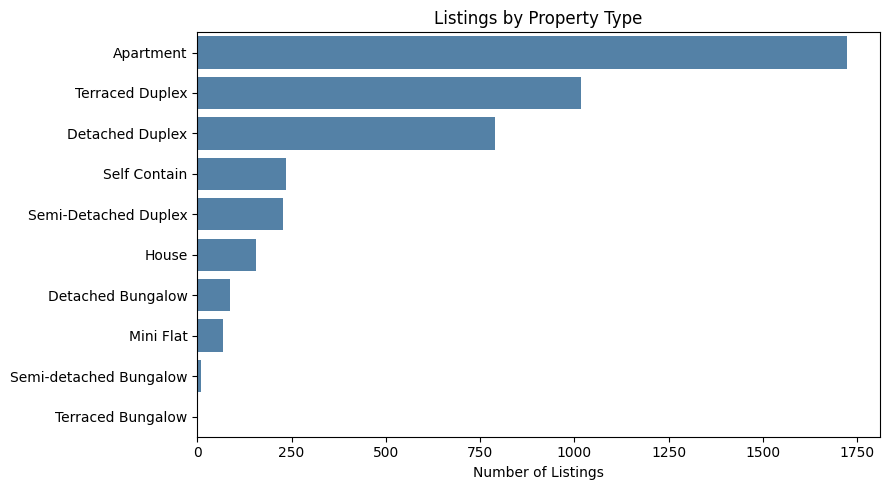

In [56]:
plt.figure(figsize=(9, 5))
order = df['Property Type'].value_counts().index
sns.countplot(data=df, y='Property Type', order=order, color='steelblue')
plt.title('Listings by Property Type')
plt.xlabel('Number of Listings')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [59]:
print(df['Source'].value_counts())

Source
NPC            1738
PropertyPro    1692
Jiji            885
Name: count, dtype: int64


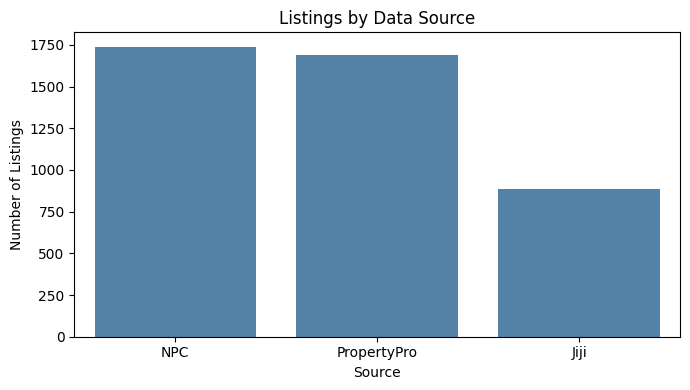

In [58]:
plt.figure(figsize=(7, 4))
order = df['Source'].value_counts().index
sns.countplot(data=df, x='Source', order=order, color='steelblue')
plt.title('Listings by Data Source')
plt.xlabel('Source')
plt.ylabel('Number of Listings')
plt.tight_layout()
plt.show()

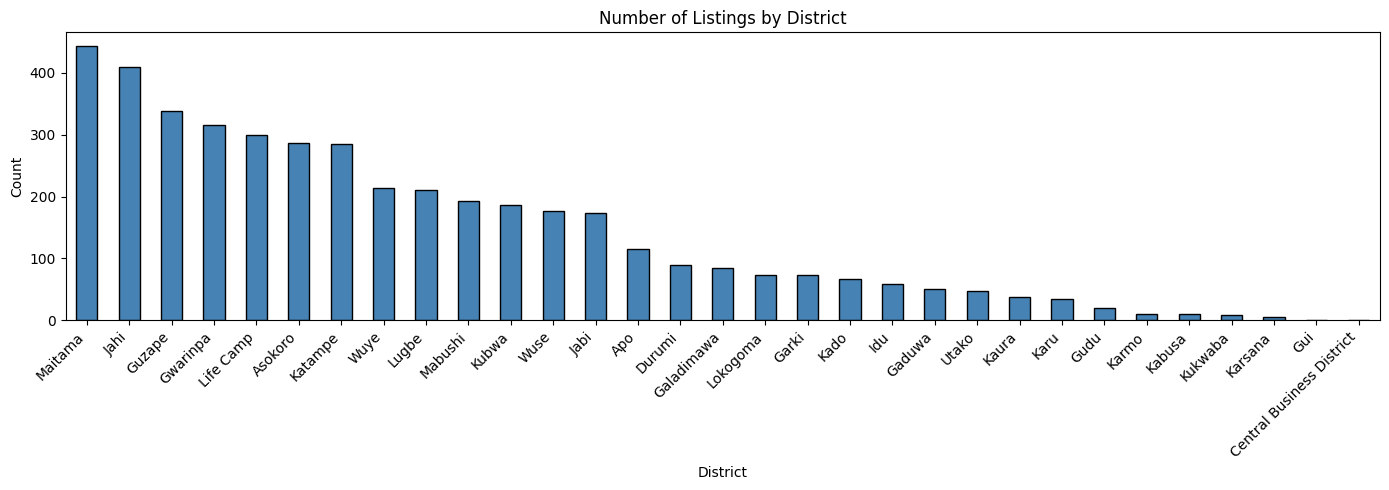

In [62]:
district_counts = df['District'].value_counts()
plt.figure(figsize=(14, 5))
district_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Number of Listings by District')
plt.xlabel('District')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Maitama, Jahi, Guzape, and Gwarinpa account for a large proportion of listings. A handful of districts (Gui, Central Business District, Karsana, Kukwaba) have fewer than 10 listings each.

In [68]:
avg_rent = df.groupby('District')['Price (Per Annum)'].mean().sort_values(ascending=False)

print("Most Expensive Districts (avg annual rent):")
for district, price in avg_rent.head(10).items():
    print(f"  {district:<30} ₦{price:>15,.0f}")

print("Least Expensive Districts (avg annual rent):")
for district, price in avg_rent.tail(10).items():
    print(f"  {district:<30} ₦{price:>15,.0f}")

Most Expensive Districts (avg annual rent):
  Central Business District      ₦    123,338,700
  Maitama                        ₦     40,327,962
  Asokoro                        ₦     28,875,858
  Wuse                           ₦     25,145,088
  Guzape                         ₦     22,047,633
  Jabi                           ₦     21,586,453
  Kukwaba                        ₦     16,750,000
  Kado                           ₦     16,616,667
  Wuye                           ₦     16,482,944
  Katampe                        ₦     15,192,254
Least Expensive Districts (avg annual rent):
  Gwarinpa                       ₦      7,668,900
  Idu                            ₦      6,618,644
  Galadimawa                     ₦      6,545,882
  Karmo                          ₦      6,500,000
  Lokogoma                       ₦      6,100,000
  Lugbe                          ₦      4,907,857
  Kubwa                          ₦      4,246,524
  Kabusa                         ₦      2,918,182
  Karu     

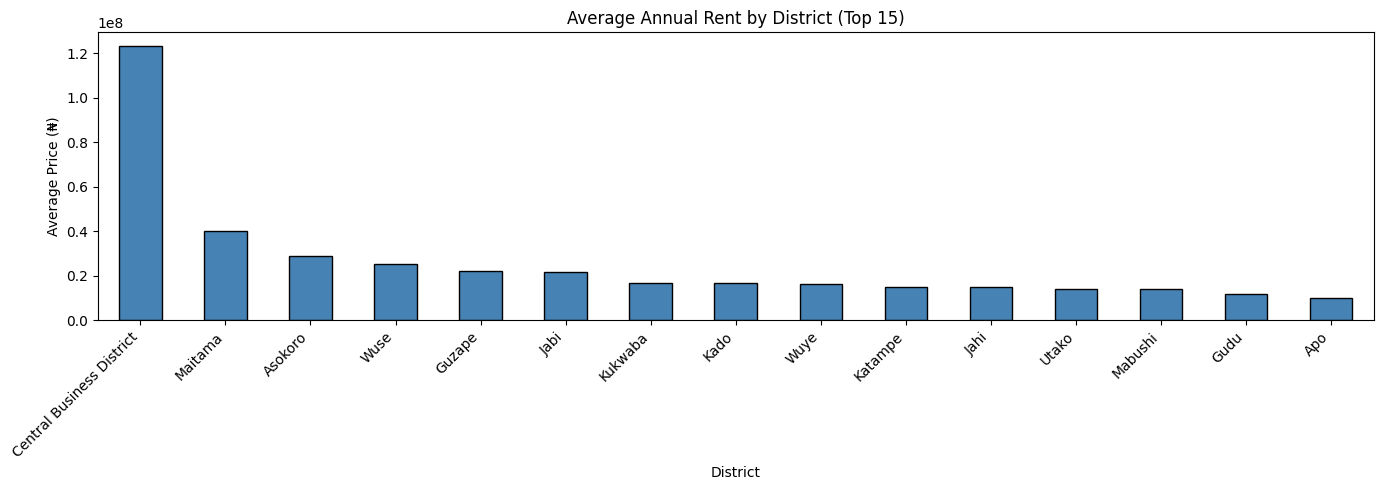

In [69]:
top15_avg = avg_rent.head(15)

plt.figure(figsize=(14, 5))
top15_avg.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Annual Rent by District (Top 15)')
plt.xlabel('District')
plt.ylabel('Average Price (₦)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

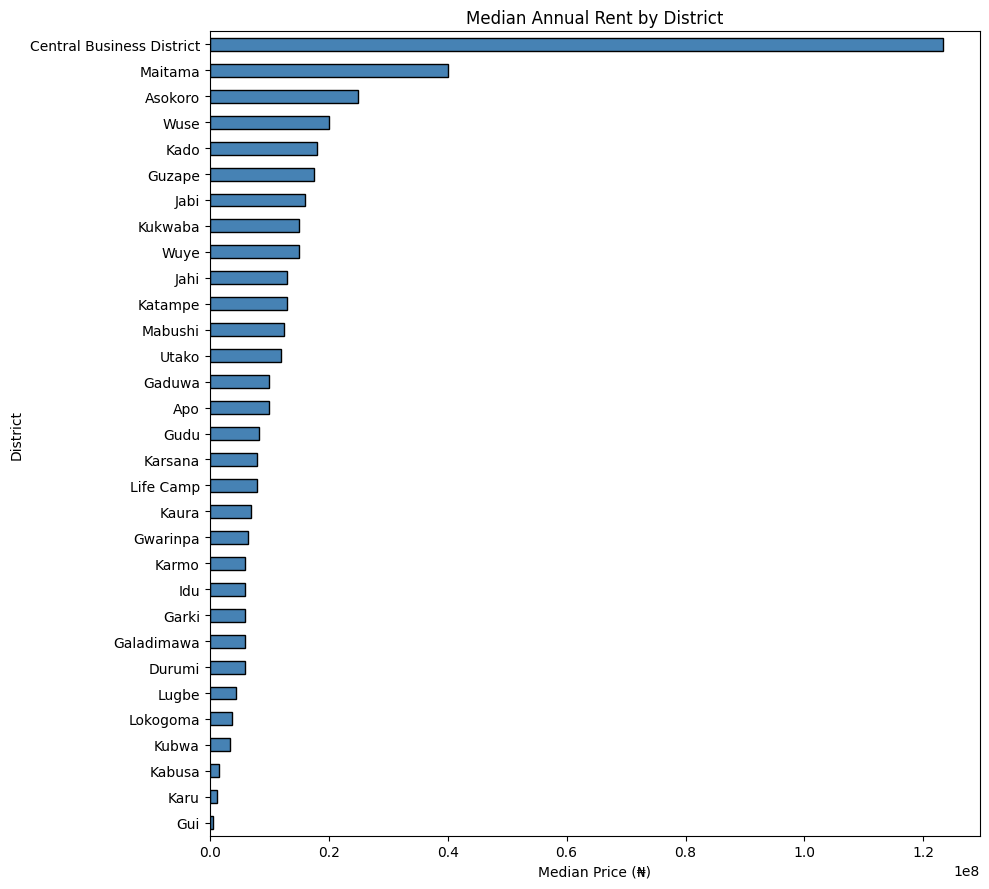

In [70]:
median_rent_district = df.groupby('District')['Price (Per Annum)'].median().sort_values(ascending=True)

plt.figure(figsize=(10, 9))
median_rent_district.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Median Annual Rent by District')
plt.xlabel('Median Price (₦)')
plt.tight_layout()
plt.show()

### Bedrooms vs Rent

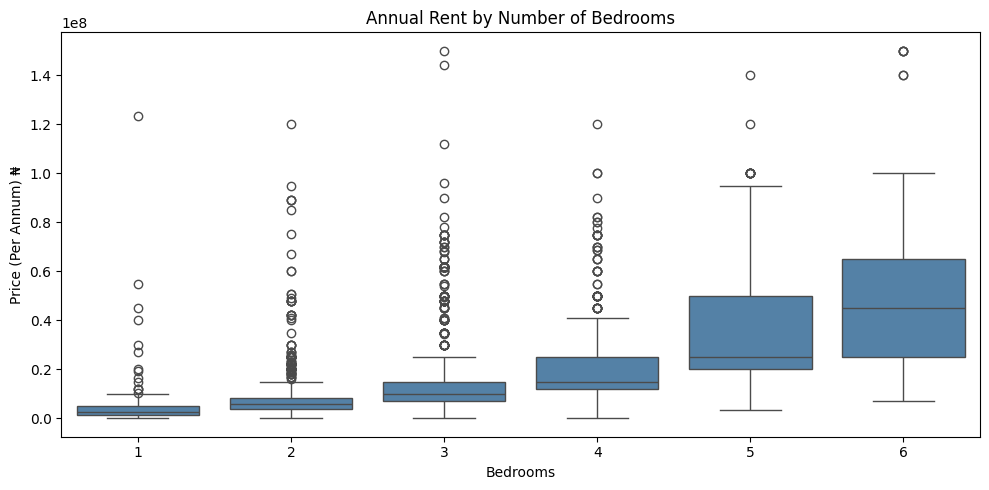

Median rent by bedroom count:
  1 bedroom(s): ₦   2,500,000
  2 bedroom(s): ₦   6,000,000
  3 bedroom(s): ₦  10,000,000
  4 bedroom(s): ₦  15,000,000
  5 bedroom(s): ₦  25,000,000
  6 bedroom(s): ₦  45,000,000


In [72]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Bedrooms', y='Price (Per Annum)', color='steelblue')
plt.title('Annual Rent by Number of Bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Price (Per Annum) ₦')
plt.tight_layout()
plt.show()

print("Median rent by bedroom count:")
median_by_bed = df.groupby('Bedrooms')['Price (Per Annum)'].median()
for bed, price in median_by_bed.items():
    print(f"  {bed} bedroom(s): ₦{price:>12,.0f}")

### Property Type vs Rent

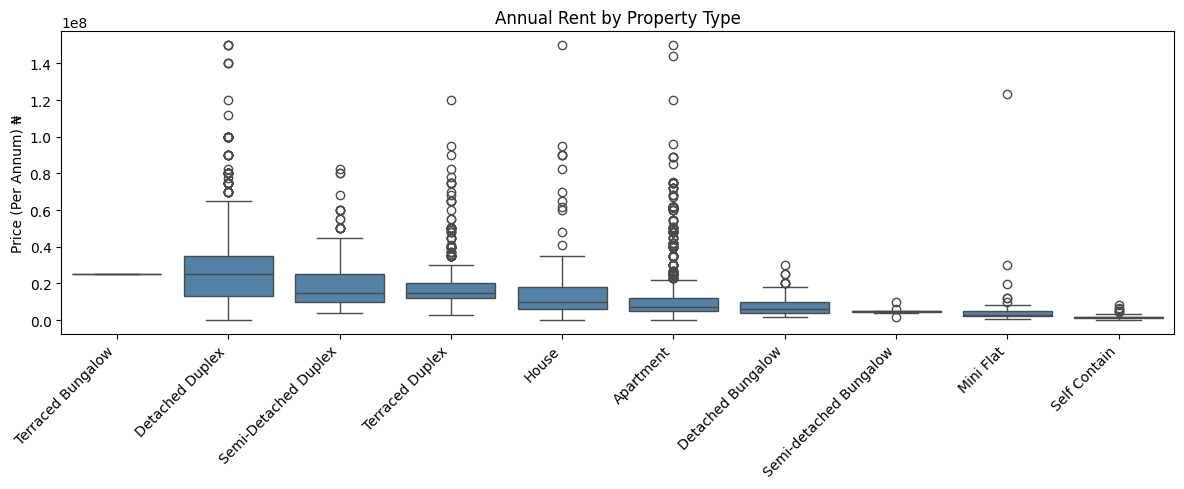

Median rent by property type:
  Terraced Bungalow         ₦  25,000,000
  Detached Duplex           ₦  25,000,000
  Semi-Detached Duplex      ₦  15,000,000
  Terraced Duplex           ₦  15,000,000
  House                     ₦  10,000,000
  Apartment                 ₦   7,000,000
  Detached Bungalow         ₦   6,000,000
  Semi-detached Bungalow    ₦   5,000,000
  Mini Flat                 ₦   3,000,000
  Self Contain              ₦   1,500,000


In [74]:
order = df.groupby('Property Type')['Price (Per Annum)'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='Property Type', y='Price (Per Annum)', order=order, color='steelblue')
plt.title('Annual Rent by Property Type')
plt.xlabel('')
plt.ylabel('Price (Per Annum) ₦')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Median rent by property type:")
med_by_type = df.groupby('Property Type')['Price (Per Annum)'].median().sort_values(ascending=False)
for ptype, price in med_by_type.items():
    print(f"  {ptype:<25} ₦{price:>12,.0f}")

### Property Category vs Rent

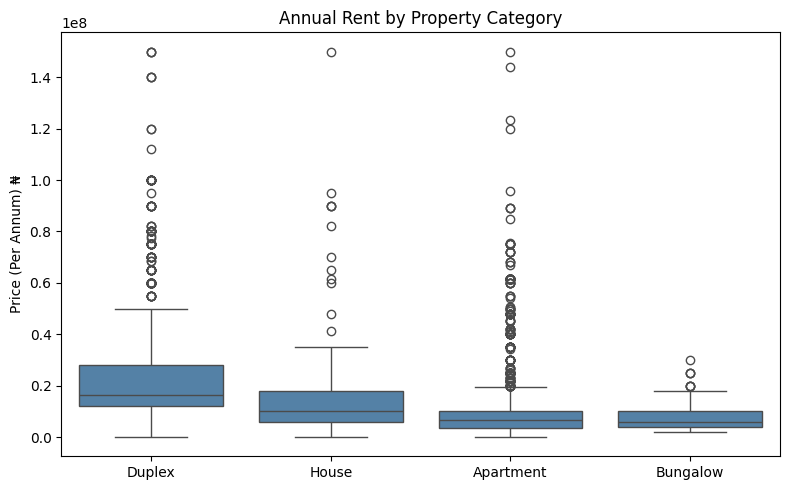

Median rent by property category:
  Duplex          ₦  16,500,000
  House           ₦  10,000,000
  Apartment       ₦   6,500,000
  Bungalow        ₦   5,750,000


In [76]:
order = df.groupby('Property Category')['Price (Per Annum)'].median().sort_values(ascending=False).index

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Property Category', y='Price (Per Annum)', order=order, color='steelblue')
plt.title('Annual Rent by Property Category')
plt.xlabel('')
plt.ylabel('Price (Per Annum) ₦')
plt.tight_layout()
plt.show()

print("Median rent by property category:")
for cat, price in df.groupby('Property Category')['Price (Per Annum)'].median().sort_values(ascending=False).items():
    print(f"  {cat:<15} ₦{price:>12,.0f}")

### Relationships With Rent

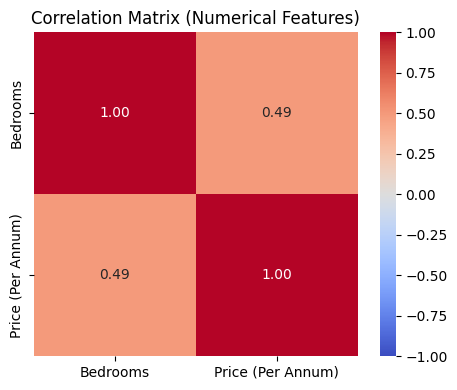

                   Bedrooms  Price (Per Annum)
Bedrooms           1.000000           0.494743
Price (Per Annum)  0.494743           1.000000


In [77]:
num_df = df[['Bedrooms', 'Price (Per Annum)']].copy()
corr = num_df.corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix (Numerical Features)')
plt.tight_layout()
plt.show()

print(corr)

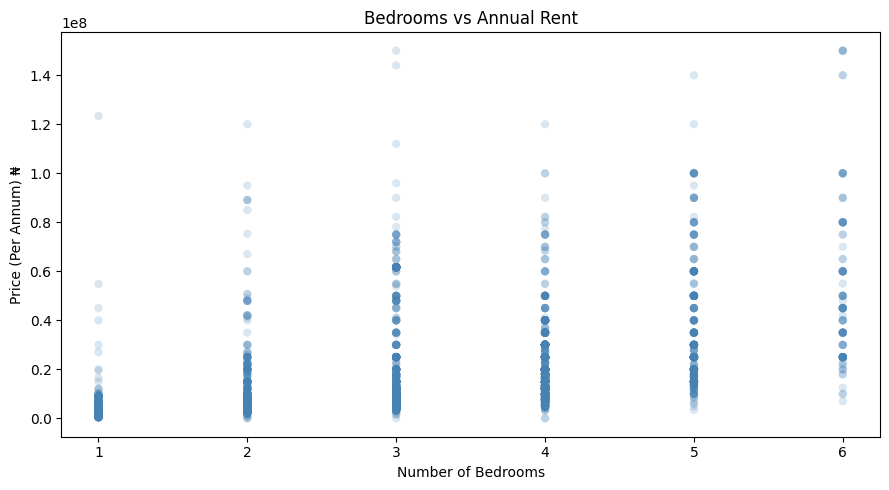

In [78]:
plt.figure(figsize=(9, 5))
plt.scatter(df['Bedrooms'], df['Price (Per Annum)'], alpha=0.2, color='steelblue', edgecolors='none')
plt.title('Bedrooms vs Annual Rent')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price (Per Annum) ₦')
plt.tight_layout()
plt.show()

In [80]:
# median rent across bedrooms, split by property category
pivot = df.groupby(['Bedrooms', 'Property Category'])['Price (Per Annum)'].median().unstack()
print("Median rent (₦) — Bedrooms x Property Category:")
print(pivot.map(lambda x: f"₦{x:,.0f}" if pd.notna(x) else "—"))

Median rent (₦) — Bedrooms x Property Category:
Property Category    Apartment     Bungalow       Duplex        House
Bedrooms                                                             
1                   ₦2,500,000   ₦2,500,000  ₦30,000,000   ₦3,250,000
2                   ₦6,000,000   ₦4,250,000   ₦6,750,000  ₦10,000,000
3                   ₦9,000,000   ₦6,000,000  ₦11,000,000  ₦10,000,000
4                  ₦15,000,000  ₦10,000,000  ₦15,000,000  ₦13,000,000
5                  ₦18,500,000  ₦20,000,000  ₦25,000,000  ₦25,000,000
6                            —            —  ₦45,000,000  ₦25,000,000


In [81]:
min_listings = 10

district_counts = df['District'].value_counts()
valid_districts = district_counts[district_counts >= min_listings].index

df = df[df['District'].isin(valid_districts)].reset_index(drop=True)

print(f"Districts kept   : {len(valid_districts)}")
print(f"Districts dropped: {district_counts[district_counts < min_listings].index.tolist()}")
print(f"Rows remaining   : {len(df)}")

Districts kept   : 27
Districts dropped: ['Kukwaba', 'Karsana', 'Gui', 'Central Business District']
Rows remaining   : 4300
